In [1]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123
AUTOTUNE = tf.data.AUTOTUNE

def load(path, **kwargs):
    return tf.keras.utils.image_dataset_from_directory(
        path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, **kwargs
    )

train_ds = load("dataset/Train", shuffle=True, seed=SEED)
val_ds = load("dataset/Validation", shuffle=False)
test_ds = load("dataset/Test", shuffle=False)

class_names = train_ds.class_names
print("Classes:", class_names)

# Classes are balanced (149 vs 150), so class weights are not needed.
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 299 files belonging to 2 classes.
Found 62 files belonging to 2 classes.
Found 22 files belonging to 2 classes.
Classes: ['Defective', 'Non defective']


In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.12),
    tf.keras.layers.RandomContrast(0.10),
], name="augmentation")

# EfficientNetB3 backbone: fine-tune only the last ~120 layers,
# keeping BatchNorm layers frozen for stable transfer learning.
base_model = tf.keras.applications.EfficientNetB3(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = True
for layer in base_model.layers[:-120]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.35)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,791,216 (41.17 MB)

 Trainable params: 8,457,407 (32.26 MB)

 Non-trainable params: 2,333,809 (8.90 MB)

In [5]:
print(len(model.layers))

7


In [7]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras", monitor="val_accuracy",
        save_best_only=True, mode="max", verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25


c:\Users\samya\Desktop\Railway\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6455 - auc: 0.6909 - loss: 0.7429
Epoch 1: val_accuracy improved from None to 0.75806, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.6455 - auc: 0.6909 - loss: 0.7429 - val_accuracy: 0.7581 - val_auc: 0.8829 - val_loss: 0.5474 - learning_rate: 1.0000e-04
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8060 - auc: 0.8882 - loss: 0.4254   
Epoch 2: val_accuracy did not improve from 0.75806
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.8060 - auc: 0.8882 - loss: 0.4254 - val_accuracy: 0.7419 - val_auc: 0.8985 - val_loss: 0.5192 - learning_rate: 1.0000e-04
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8562 - auc: 0.9433 - loss: 0.2989
Epoch 3: val_accuracy improved from 0.75806 to 0.82258, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/ste

In [ ]:
# Final evaluation
loss, acc, auc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {loss:.4f} | accuracy: {acc:.4f} | AUC: {auc:.4f}")

y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_pred = (model.predict(test_ds, verbose=0).ravel() >= 0.5).astype(int)
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Test loss: 0.1766 | accuracy: 0.9545 | AUC: 0.9835

Confusion Matrix:
[[11  0]
 [ 1 10]]

Classification Report:
               precision    recall  f1-score   support

    Defective     0.9167    1.0000    0.9565        11
Non defective     1.0000    0.9091    0.9524        11

     accuracy                         0.9545        22
    macro avg     0.9583    0.9545    0.9545        22
 weighted avg     0.9583    0.9545    0.9545        22



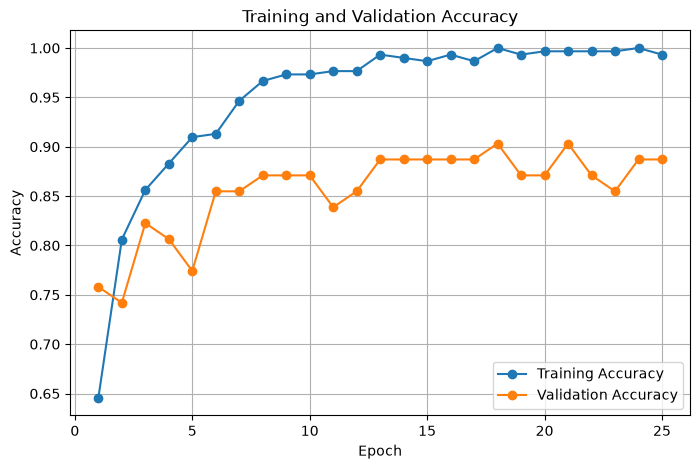

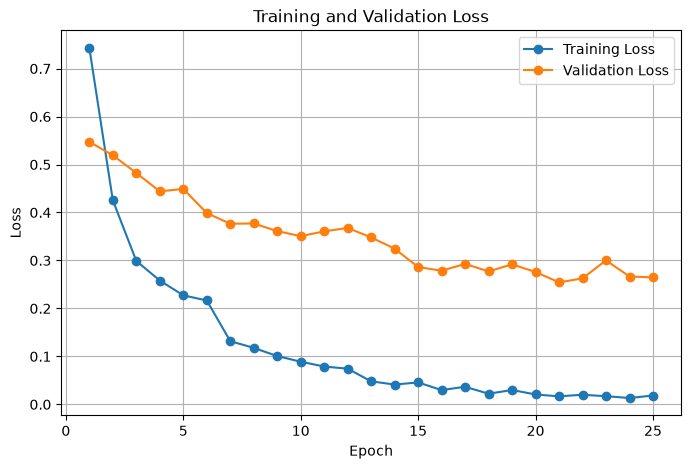

In [11]:
import matplotlib.pyplot as plt

# Get training history
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

# -------------------------------
# Accuracy Graph
# -------------------------------
plt.figure(figsize=(8, 5))

plt.plot(epochs, acc, marker="o", label="Training Accuracy")
plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()


# -------------------------------
# Loss Graph
# -------------------------------
plt.figure(figsize=(8, 5))

plt.plot(epochs, loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()